<a href="https://colab.research.google.com/github/UAMCAntwerpen/2040FBDBIC/blob/main/07_QSAR_models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Install RDKit

In [1]:
!pip install rdkit-pypi

     |████████████████████████████████| 18.6 MB 1.2 MB/s 


In [2]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit import DataStructs

## Linear regression  models

In [ ]:
# Load a DPP4 dataset
import requests

url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/main/dpp4.pIC50.txt"
data = requests.get(url).text.split("\n")
print(data[0])

N[C@H](C(=O)N1CC[C@H](F)C1)C1CCC(NS(=O)(=O)c2ccc(F)cc2F)CC1	7.32


In [ ]:
# Split into smiles, mols, fps and pic50
import numpy as np

mols = []
smiles = []
fps = []
pic50 = []
for d in data:
  fields = d.split()
  if len(fields) < 1: continue
  smiles.append(fields[0])
  pic50.append(float(fields[1]))
  mol = Chem.MolFromSmiles(fields[0])
  mols.append(mol)
  fp = np.zeros((0,), dtype=np.int8)
  DataStructs.ConvertToNumpyArray(Chem.RDKFingerprint(mol), fp)
  fps.append(fp)
print(smiles[0])
print(pic50[0])
print(fps[0])
print(max(pic50))
print(min(pic50))
print(len(smiles))


N[C@H](C(=O)N1CC[C@H](F)C1)C1CCC(NS(=O)(=O)c2ccc(F)cc2F)CC1
7.32
[0 1 1 ... 1 0 1]
10.92
4.0
3858


In [ ]:
# Create a training set (70%) and a test set (30%)
from sklearn.model_selection import train_test_split

pic50_train, pic50_test, fps_train, fps_test = train_test_split(pic50, fps, test_size=0.3, random_state=42)
print(len(pic50_train), len(pic50_test))

2700 1158


In [ ]:
# Train a linear regression model
from sklearn import linear_model

model = linear_model.LinearRegression()
model.fit(fps_train, pic50_train)
print(model.coef_)

[-1.19183471  1.14758749  0.77929443 ...  0.18272035  0.82914222
 -3.20376615]


In [ ]:
# Apply the trained model on the test set and compare the predicted values with the experimental ones
pic50_pred = model.predict(fps_test)
print(pic50_pred)

[ 5.04302546  7.70686352 10.78220042 ...  7.14680847  9.82744807
  7.41976824]


MSE =  13.05943717969174


Text(0, 0.5, 'Predicted values')

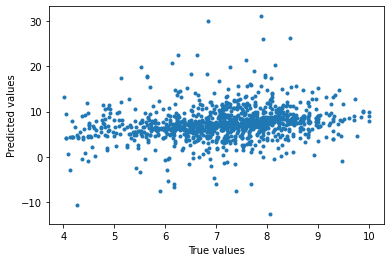

In [ ]:
# Validate the model by calculating the MSE of the predictions when compared to the true values
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

print("MSE = ", mean_squared_error(pic50_test, pic50_pred))
plt.plot(pic50_test, pic50_pred, '.')
plt.xlabel("True values")
plt.ylabel("Predicted values")

In [ ]:
# Repeat the test/train splitting a number of times in order to get statistics
for i in range(10):
  pic50_train, pic50_test, fps_train, fps_test = train_test_split(pic50, fps, test_size=0.3)
  model.fit(fps_train, pic50_train)
  pic50_pred = model.predict(fps_test)
  print("MSE = ", mean_squared_error(pic50_test, pic50_pred))

MSE =  13.291682181713728
MSE =  10.433434554942918
MSE =  9.228673493838894
MSE =  10.743526420349546
MSE =  11.970830979449916
MSE =  10.968168442546132
MSE =  9.793261869043409
MSE =  8.296659749935174
MSE =  7.8113761993556245
MSE =  8.61045583757804


## Neural network

MSE =  0.7616512811127821


Text(0, 0.5, 'Predicted values')

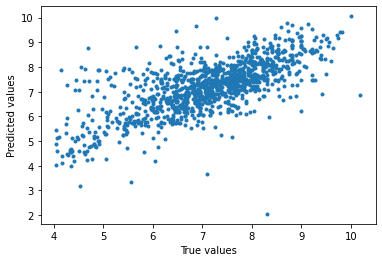

In [ ]:
# Neural network regressor
from sklearn.neural_network import MLPRegressor
model = MLPRegressor(random_state=1, max_iter=500)
model.fit(fps_train, pic50_train)
pic50_pred = model.predict(fps_test)
print("MSE = ", mean_squared_error(pic50_test, pic50_pred))
plt.plot(pic50_test, pic50_pred, '.')
plt.xlabel("True values")
plt.ylabel("Predicted values")

In [ ]:
# Repeat the test/train splitting a number of times in order to get statistics
for i in range(10):
  pic50_train, pic50_test, fps_train, fps_test = train_test_split(pic50, fps, test_size=0.3)
  model.fit(fps_train, pic50_train)
  pic50_pred = model.predict(fps_test)
  print("MSE = ", mean_squared_error(pic50_test, pic50_pred))

MSE =  0.6644963375348402
MSE =  0.7160331840132822
MSE =  0.6781263093606983
MSE =  0.6923602988005725
MSE =  0.7563247139534424
MSE =  0.7541057885521583
MSE =  0.6798248378152293
MSE =  0.7771547677446847
MSE =  0.8100222721653414
MSE =  0.7491205833623518


In [ ]:
# Now built a model using the entire dataset and save for later on
pic50_predictor = MLPRegressor(max_iter=500)
pic50_predictor.fit(fps, pic50)

MLPRegressor(activation='relu', alpha=0.0001, batch_size='auto', beta_1=0.9,
             beta_2=0.999, early_stopping=False, epsilon=1e-08,
             hidden_layer_sizes=(100,), learning_rate='constant',
             learning_rate_init=0.001, max_fun=15000, max_iter=500,
             momentum=0.9, n_iter_no_change=10, nesterovs_momentum=True,
             power_t=0.5, random_state=None, shuffle=True, solver='adam',
             tol=0.0001, validation_fraction=0.1, verbose=False,
             warm_start=False)

## Random forest classifier

In [ ]:
# Load a DPP4 dataset (actives versus non-actives)
url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/main/dpp4.classified.txt"
data = requests.get(url).text.split("\n")
print(data[0])

COc1cc(OC)cc(c1)c2nc(N)c(CN)c(n2)c3ccc(Cl)cc3Cl	ACTIVE


In [ ]:
# Generate fingerprints and make list of activities
activities = []
fps = []
for d in data:
  if d is None or d == "": continue
  fields = d.split()
  if fields[1] == "ACTIVE": activities.append(1)
  if fields[1] == "INACTIVE": activities.append(0)
  mol = Chem.MolFromSmiles(fields[0])
  fp = np.zeros((0,), dtype=np.int8)
  DataStructs.ConvertToNumpyArray(Chem.RDKFingerprint(mol), fp)
  fps.append(fp)

print(len(activities), len(fps))

13858 13858


In [ ]:
# Random forest model
from sklearn.ensemble import RandomForestClassifier

act_train, act_test, fps_train, fps_test = train_test_split(activities, fps, test_size=0.3)
model = RandomForestClassifier(max_depth=2)
model.fit(fps_train, act_train)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=2, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
# Calculate the accurcay of the generated model
from sklearn.metrics import accuracy_score

prediction = model.predict(fps_test)
print(accuracy_score(act_test, prediction))

0.789081289081289


In [ ]:
# Now optimise the model by exploring the max_depth parameter
for max_depth in range(1,10):
  accuracy = []
  for i in range(10):
    act_train, act_test, fps_train, fps_test = train_test_split(activities, fps, test_size=0.3)
    model = RandomForestClassifier(max_depth=max_depth)
    model.fit(fps_train, act_train)
    prediction = model.predict(fps_test)
    accuracy.append(accuracy_score(act_test, prediction))
  print("Max_depth: %d -> accuracy = %.3f" % (max_depth, np.mean(accuracy)))

Max_depth: 1 -> accuracy = 0.725
Max_depth: 2 -> accuracy = 0.790
Max_depth: 3 -> accuracy = 0.896
Max_depth: 4 -> accuracy = 0.930
Max_depth: 5 -> accuracy = 0.944
Max_depth: 6 -> accuracy = 0.961
Max_depth: 7 -> accuracy = 0.971
Max_depth: 8 -> accuracy = 0.977
Max_depth: 9 -> accuracy = 0.984


In [ ]:
# Now train a RF model with all data and max_depth = 5
model = RandomForestClassifier(max_depth=5)
model.fit(fps, activities)

RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                       criterion='gini', max_depth=5, max_features='auto',
                       max_leaf_nodes=None, max_samples=None,
                       min_impurity_decrease=0.0, min_impurity_split=None,
                       min_samples_leaf=1, min_samples_split=2,
                       min_weight_fraction_leaf=0.0, n_estimators=100,
                       n_jobs=None, oob_score=False, random_state=None,
                       verbose=0, warm_start=False)

In [ ]:
# Apply this model on a database of 100k compounds and search for DPP4 actives
url = "https://raw.githubusercontent.com/UAMCAntwerpen/2040FBDBIC/main/compounds_100k.smi"
data = requests.get(url).text.split("\n")
print(data[0])

COc1cccc(-n2c(-c3cccs3)cn3c4c(=O)n(C)c(=O)n(C)c4nc23)c1


In [ ]:
db_fps = []
for d in data:
  if d == "" or d is None: continue
  mol = Chem.MolFromSmiles(d)
  fp = np.zeros((0,), dtype=np.int8)
  DataStructs.ConvertToNumpyArray(Chem.RDKFingerprint(mol), fp)
  db_fps.append(fp)

In [ ]:
# Apply the RF on the database and isolate those that are predicted to be active
prediction = model.predict(db_fps)
hits_smiles = []
hits_fps = []
for i in range(len(prediction)):
  if prediction[i] == 1:
    hits_smiles.append(data[i])
    hits_fps.append(db_fps[i])
print(len(hits_smiles), len(hits_fps))

1257 1257


In [ ]:
# Score the identified hits with the pIC50 model
hits_pic50 = pic50_predictor.predict(hits_fps)

9.456626867015055
CN(C)c1ccc([C@@H]2[C@@H](C(=O)c3ccccc3)N3N=Cc4ccccc4C3[C@H]2[N+](=O)[O-])cc1


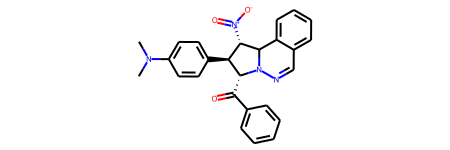

In [ ]:
# Identify the compound with the highest pIC50 and show structure
best_pic50 = 0
best_smiles = ""
for i in range(len(hits_pic50)):
  if hits_pic50[i] > best_pic50:
    best_pic50 = hits_pic50[i]
    best_smiles = hits_smiles[i]
print(best_pic50)
print(best_smiles)
mol = Chem.MolFromSmiles(best_smiles)
mol

## Validation

#### Performance metrics

In [ ]:
# Real data
real = np.array([1,1,1,1,0,0,1,0,1,0,1,0,1,1,0,0,1,0,1,1])

# Predictions from a good model
good = np.array([1,0,1,1,0,1,1,0,1,0,1,0,1,0,0,0,1,0,1,1])

# Predictions from a bad model
bad = np.array([0,0,0,0,1,1,0,1,0,1,0,1,0,0,1,1,0,1,0,0])

# Predictions from a random model
random = np.random.randint(2, size=20)

print("Real  ", real)
print("Good  ", good)
print("Bad   ", bad)
print("Random", random)

Real   [1 1 1 1 0 0 1 0 1 0 1 0 1 1 0 0 1 0 1 1]
Good   [1 0 1 1 0 1 1 0 1 0 1 0 1 0 0 0 1 0 1 1]
Bad    [0 0 0 0 1 1 0 1 0 1 0 1 0 0 1 1 0 1 0 0]
Random [1 1 1 1 1 0 0 0 1 1 1 0 1 1 0 1 0 1 1 1]


In [ ]:
# Function to calculate number of true positives
def TP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false positives
def FP(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 1: n += 1
  return float(n)

In [ ]:
# Function to calculate number of true negatives
def TN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 0 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Function to calculate number of false negatives
def FN(real, pred):
  n = 0
  for i in range(len(real)):
    if real[i] == 1 and pred[i] == 0: n += 1
  return float(n)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TP", TP(real, good))
print("TN", TN(real, good))
print("FP", FP(real, good))
print("FN", FN(real, good))

# 2. Bad model
print("Bad model")
print("TP", TP(real, bad))
print("TN", TN(real, bad))
print("FP", FP(real, bad))
print("FN", FN(real, bad))

# 3. Random model
print("Random model")
print("TP", TP(real, random))
print("TN", TN(real, random))
print("FP", FP(real, random))
print("FN", FN(real, random))

Good model
TP 10.0
TN 7.0
FP 1.0
FN 2.0
Bad model
TP 0.0
TN 0.0
FP 8.0
FN 12.0
Random model
TP 10.0
TN 4.0
FP 4.0
FN 2.0


In [ ]:
# Rates
def TPR(real, pred):
  tp = TP(real, pred)
  fn = FN(real, pred)
  return tp / (tp + fn)

def TNR(real, pred):
  tn = TN(real, pred)
  fp = FP(real, pred)
  return tn / (tn + fp)

def FPR(real, pred):
  fp = FP(real, pred)
  tn = TN(real, pred)
  return fp / (fp + tn)

def FNR(real, pred):
  fn = FN(real, pred)
  tp = TP(real, pred)
  return fn / (fn + tp)

In [ ]:
# Apply metrics onto the three models

# 1. Good model
print("Good model")
print("TPR", TPR(real, good))
print("TNR", TNR(real, good))
print("FPR", FPR(real, good))
print("FNR", FNR(real, good))

# 2. Bad model
print("Bad model")
print("TPR", TPR(real, bad))
print("TNR", TNR(real, bad))
print("FPR", FPR(real, bad))
print("FNR", FNR(real, bad))

# 3. Random model
print("Random model")
print("TPR", TPR(real, random))
print("TNR", TNR(real, random))
print("FPR", FPR(real, random))
print("FNR", FNR(real, random))

Good model
TPR 0.8333333333333334
TNR 0.875
FPR 0.125
FNR 0.16666666666666666
Bad model
TPR 0.0
TNR 0.0
FPR 1.0
FNR 1.0
Random model
TPR 0.8333333333333334
TNR 0.5
FPR 0.5
FNR 0.16666666666666666


Text(0, 0.5, 'Number of FN (blue) and TP (red)')

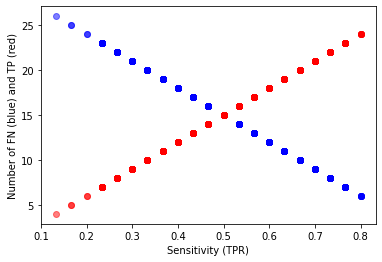

In [ ]:
# Trade-off between sensitivity (TPR), number of false negatives (FN) and true positives (TP)
import matplotlib.pyplot as plt

real = np.array([0,1]*30)

sensitivities = []
true_positives = []
false_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  sensitivities.append(TPR(real, model))
  false_negatives.append(FN(real, model))
  true_positives.append(TP(real, model))
plt.scatter(sensitivities, false_negatives, c="blue", alpha=0.5)
plt.scatter(sensitivities, true_positives, c="red", alpha=0.5)
plt.xlabel("Sensitivity (TPR)")
plt.ylabel("Number of FN (blue) and TP (red)")

Text(0, 0.5, 'Number of FP (blue) and TN (red)')

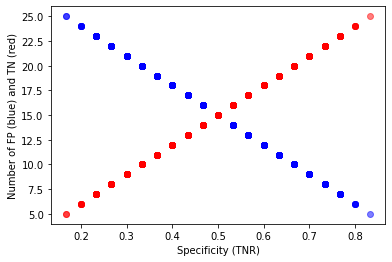

In [ ]:
# Relation between specificity (TNR), number of false positives (FP) and true negatives (TN)
real = np.array([0,1]*30)

specificities = []
false_positives = []
true_negatives = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  specificities.append(TNR(real,model))
  false_positives.append(FP(real,model))
  true_negatives.append(TN(real,model))
plt.scatter(specificities, false_positives, c="blue", alpha=0.5)
plt.scatter(specificities, true_negatives, c="red", alpha=0.5)
plt.xlabel("Specificity (TNR)")
plt.ylabel("Number of FP (blue) and TN (red)")

Text(0, 0.5, 'Precision (blue) and sensitivity (red)')

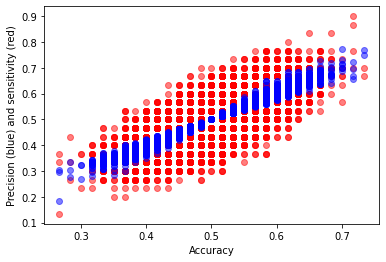

In [ ]:
# Relation between accuracy, precision and sensitivity
real = np.array([0,1]*30)

P = []
A = []
S = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  precision = (tp / (tp + fp))
  accuracy = (tp + tn) / (tp + fp + fn + tn)
  sensitivity = tp / (tp + fn)
  P.append(precision)
  A.append(accuracy)
  S.append(sensitivity)
plt.scatter(A, S, c="red", alpha=0.5)
plt.scatter(A, P, c="blue", alpha=0.5)
plt.xlabel("Accuracy")
plt.ylabel("Precision (blue) and sensitivity (red)")

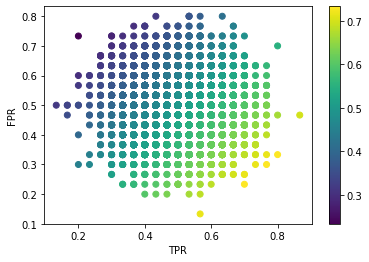

In [ ]:
# TPR and FPR: accuracy as a metric that balances high TPR and low FPR
real = np.array([0,1]*30)

TPRS = []
FPRS = []
ACCU = []
for i in range(10000):
  model = np.random.randint(2, size=60)
  tp = TP(real,model)
  fp = FP(real,model)
  tn = TN(real,model)
  fn = FN(real,model)
  TPRS.append(tp / (tp + fn))
  FPRS.append(fp / (fp + tn))
  ACCU.append((tp + tn) / (tp + fp + fn + tn))
plt.scatter(TPRS, FPRS, c=ACCU)
plt.xlabel("TPR")
plt.ylabel("FPR")
plt.colorbar()